In [1]:
import os
import re
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
!pip install -q gdown

!gdown --fuzzy "https://drive.google.com/file/d/1D1Z0iTfxjNrWi9qkqEp7uqlL0X36QcXO/view?usp=sharing" -O /content/Tell2Design_Data.zip

Downloading...
From (original): https://drive.google.com/uc?id=1D1Z0iTfxjNrWi9qkqEp7uqlL0X36QcXO
From (redirected): https://drive.google.com/uc?id=1D1Z0iTfxjNrWi9qkqEp7uqlL0X36QcXO&confirm=t&uuid=2c56013c-d609-4dd9-8c19-1e0125c020b7
To: /content/Tell2Design_Data.zip
100% 706M/706M [00:17<00:00, 40.5MB/s]


In [3]:
import os
print(os.path.getsize('/content/Tell2Design_Data.zip'))

706363868


In [4]:
!unzip -q "/content/Tell2Design_Data.zip" -d /content/tell2design

In [5]:
!find /content/tell2design -maxdepth 3 -type d

/content/tell2design
/content/tell2design/Tell2Design Data
/content/tell2design/Tell2Design Data/Separated Data
/content/tell2design/Tell2Design Data/Separated Data/eval_data
/content/tell2design/Tell2Design Data/Separated Data/1st_finetune_data
/content/tell2design/Tell2Design Data/Separated Data/2nd_finetune_data
/content/tell2design/Tell2Design Data/General Data
/content/tell2design/Tell2Design Data/General Data/floorplan_image
/content/tell2design/Tell2Design Data/General Data/human_annotated_tags


In [6]:
!find /content/tell2design -type f | head -30

/content/tell2design/Tell2Design Data/Separated Data/eval_data/Imagen/tags/28980.txt
/content/tell2design/Tell2Design Data/Separated Data/eval_data/Imagen/tags/42272.txt
/content/tell2design/Tell2Design Data/Separated Data/eval_data/Imagen/tags/26448.txt
/content/tell2design/Tell2Design Data/Separated Data/eval_data/Imagen/tags/45508.txt
/content/tell2design/Tell2Design Data/Separated Data/eval_data/Imagen/tags/62074.txt
/content/tell2design/Tell2Design Data/Separated Data/eval_data/Imagen/tags/43401.txt
/content/tell2design/Tell2Design Data/Separated Data/eval_data/Imagen/tags/9564.txt
/content/tell2design/Tell2Design Data/Separated Data/eval_data/Imagen/tags/59474.txt
/content/tell2design/Tell2Design Data/Separated Data/eval_data/Imagen/tags/80425.txt
/content/tell2design/Tell2Design Data/Separated Data/eval_data/Imagen/tags/9795.txt
/content/tell2design/Tell2Design Data/Separated Data/eval_data/Imagen/tags/25448.txt
/content/tell2design/Tell2Design Data/Separated Data/eval_data/Imag

In [7]:
import os
import re
import pandas as pd

img_dir = "/content/tell2design/Tell2Design Data/General Data/floorplan_image"
tag_dir = "/content/tell2design/Tell2Design Data/General Data/human_annotated_tags"

tag_files = sorted(os.listdir(tag_dir))

records = []
for fname in tag_files:
    file_id = fname.replace(".txt", "")
    img_path = os.path.join(img_dir, f"{file_id}.png")
    with open(os.path.join(tag_dir, fname), encoding="utf-8") as f:
        text = f.read().strip()
    records.append({
        "id": file_id,
        "has_image": os.path.exists(img_path),
        "caption": text,
        "word_count": len(text.split())
    })

df = pd.DataFrame(records)
print(f"Total paired records: {len(df)}")
print(f"Records with matching image: {df['has_image'].sum()}")
print(df["word_count"].describe())

Total paired records: 4003
Records with matching image: 4003
count    4003.000000
mean      193.629778
std        73.173712
min        40.000000
25%       145.000000
50%       179.000000
75%       229.000000
max       629.000000
Name: word_count, dtype: float64


In [8]:
# room type extraction — rough pass using common room keywords seen in the sample
room_keywords = ["bedroom", "master", "bathroom", "kitchen", "living room",
                  "balcony", "common room", "dining room", "garage", "closet",
                  "hallway", "office", "laundry", "storage"]

def extract_rooms(text):
    text_lower = text.lower()
    return [r for r in room_keywords if r in text_lower]

df["rooms_mentioned"] = df["caption"].apply(extract_rooms)
df["room_count"] = df["rooms_mentioned"].apply(len)

print(df["room_count"].describe())

from collections import Counter
all_rooms = [r for rooms in df["rooms_mentioned"] for r in rooms]
print(Counter(all_rooms).most_common())

count    4003.000000
mean        5.930802
std         0.814019
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max        11.000000
Name: room_count, dtype: float64
[('living room', 3944), ('master', 3937), ('bathroom', 3839), ('kitchen', 3838), ('common room', 3653), ('balcony', 3343), ('bedroom', 795), ('storage', 171), ('hallway', 118), ('dining room', 69), ('office', 17), ('closet', 16), ('laundry', 1)]


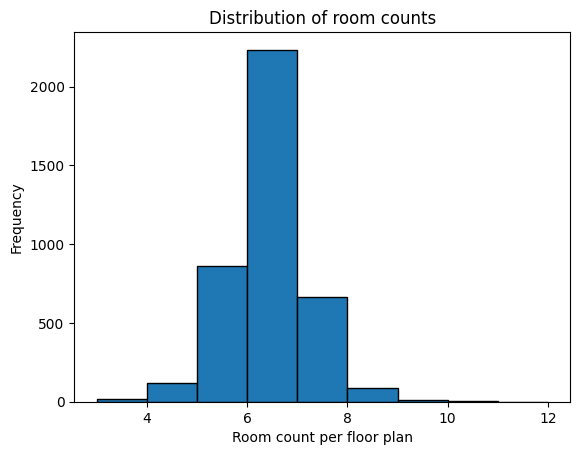

In [9]:
import matplotlib.pyplot as plt

plt.hist(df["room_count"], bins=range(3, 13), edgecolor="black")
plt.xlabel("Room count per floor plan")
plt.ylabel("Frequency")
plt.title("Distribution of room counts")
plt.show()

In [10]:
# check overlap: do captions ever mention BOTH "living room" and "common room"?
both = df[df["caption"].str.lower().str.contains("living room") & df["caption"].str.lower().str.contains("common room")]
print(f"Captions with both living room AND common room: {len(both)} / {len(df)}")
print(both.iloc[0]["caption"][:400])

Captions with both living room AND common room: 3611 / 4003
The balcony juts out on the south side, with the master to the north. It is approximately 12 feet wide by 5 feet deep, for a total square footage of 60. The bathroom is in the northeast corner with the common room to the south and the living room to the west. It is approximately 12 feet wide by 5 feet deep, for a total square footage of 60. The common room is on the east side with the bathroom to 


In [11]:
import re
import networkx as nx

room_keywords = ["bedroom", "master", "bathroom", "kitchen", "living room",
                  "balcony", "common room", "dining room", "garage", "closet",
                  "hallway", "office", "laundry", "storage"]

direction_words = ["north", "south", "east", "west", "northeast", "northwest",
                    "southeast", "southwest"]

def caption_to_graph(caption_id, text):
    G = nx.Graph()
    # split into per-room sentences (roughly one room described per sentence group)
    sentences = re.split(r'(?<=\.)\s+', text)
    for sent in sentences:
        sent_lower = sent.lower()
        room = next((r for r in room_keywords if r in sent_lower), None)
        if not room:
            continue
        dims = re.search(r"(\d+) feet wide by (\d+) feet deep.*?square footage of (\d+)", sent)
        node_attrs = {"type": room}
        if dims:
            node_attrs.update({"width": int(dims[1]), "depth": int(dims[2]), "sqft": int(dims[3])})
        G.add_node(room, **node_attrs)
        # edges: any other room type mentioned in the same sentence = adjacency
        for other in room_keywords:
            if other != room and other in sent_lower:
                G.add_edge(room, other)
    return G

# test on one example
sample = df.iloc[0]
G = caption_to_graph(sample["id"], sample["caption"])
print(f"Nodes: {G.nodes(data=True)}")
print(f"Edges: {G.edges()}")

Nodes: [('master', {'type': 'master', 'width': 15, 'depth': 30, 'sqft': 400}), ('balcony', {}), ('bathroom', {'type': 'bathroom'}), ('living room', {}), ('common room', {}), ('kitchen', {})]
Edges: [('master', 'balcony'), ('master', 'bathroom'), ('master', 'living room'), ('master', 'common room'), ('master', 'kitchen'), ('bathroom', 'living room'), ('bathroom', 'common room')]


In [12]:
def get_subject_room(sent):
    sent_stripped = sent.strip()
    for r in sorted(room_keywords, key=len, reverse=True):
        if re.match(rf"^(?:The )?{re.escape(r)}\b", sent_stripped, re.IGNORECASE):
            return r
    return None

def caption_to_graph(caption_id, text):
    G = nx.Graph()
    sentences = re.split(r'(?<=\.)\s+', text)
    current_room = None
    for sent in sentences:
        sent_lower = sent.lower()
        subj = get_subject_room(sent)
        if subj:
            current_room = subj
            if subj not in G:
                G.add_node(subj, type=subj)
            for other in room_keywords:
                if other != subj and other in sent_lower:
                    G.add_edge(subj, other)
        elif sent_lower.strip().startswith("it is approximately") and current_room:
            dims = re.search(r"(\d+) feet wide by (\d+) feet deep.*?square footage of (\d+)", sent)
            if dims:
                G.nodes[current_room].update({
                    "width": int(dims[1]), "depth": int(dims[2]), "sqft": int(dims[3])
                })
    return G

# re-test on the same sample
G = caption_to_graph(sample["id"], sample["caption"])
print(f"Nodes: {dict(G.nodes(data=True))}")
print(f"Edges: {list(G.edges())}")

Nodes: {'balcony': {'type': 'balcony', 'width': 12, 'depth': 5, 'sqft': 60}, 'master': {'width': 12, 'depth': 20, 'sqft': 240}, 'bathroom': {'type': 'bathroom', 'width': 12, 'depth': 5, 'sqft': 60}, 'living room': {'width': 15, 'depth': 30, 'sqft': 400}, 'common room': {'width': 12, 'depth': 10, 'sqft': 120}, 'kitchen': {'type': 'kitchen', 'width': 10, 'depth': 10, 'sqft': 100}}
Edges: [('balcony', 'master'), ('master', 'common room'), ('master', 'kitchen'), ('master', 'living room'), ('bathroom', 'living room'), ('bathroom', 'common room'), ('living room', 'common room'), ('living room', 'kitchen')]


In [13]:
def caption_to_graph(caption_id, text):
    G = nx.Graph()
    sentences = re.split(r'(?<=\.)\s+', text)
    current_room = None
    for sent in sentences:
        sent_lower = sent.lower()
        subj = get_subject_room(sent)
        if subj:
            current_room = subj
            if subj in G:
                G.nodes[subj]["type"] = subj   # backfill if node was auto-created earlier
            else:
                G.add_node(subj, type=subj)
            for other in room_keywords:
                if other != subj and other in sent_lower:
                    G.add_edge(subj, other)
        elif sent_lower.strip().startswith("it is approximately") and current_room:
            dims = re.search(r"(\d+) feet wide by (\d+) feet deep.*?square footage of (\d+)", sent)
            if dims:
                G.nodes[current_room].update({
                    "width": int(dims[1]), "depth": int(dims[2]), "sqft": int(dims[3])
                })
    return G

G = caption_to_graph(sample["id"], sample["caption"])
print(dict(G.nodes(data=True)))

{'balcony': {'type': 'balcony', 'width': 12, 'depth': 5, 'sqft': 60}, 'master': {'type': 'master', 'width': 12, 'depth': 20, 'sqft': 240}, 'bathroom': {'type': 'bathroom', 'width': 12, 'depth': 5, 'sqft': 60}, 'living room': {'type': 'living room', 'width': 15, 'depth': 30, 'sqft': 400}, 'common room': {'type': 'common room', 'width': 12, 'depth': 10, 'sqft': 120}, 'kitchen': {'type': 'kitchen', 'width': 10, 'depth': 10, 'sqft': 100}}


In [14]:
graphs = {}
failed = []
for _, row in df.iterrows():
    try:
        G = caption_to_graph(row["id"], row["caption"])
        if G.number_of_nodes() == 0:
            failed.append(row["id"])
        else:
            graphs[row["id"]] = G
    except Exception as e:
        failed.append(row["id"])

print(f"Successfully parsed: {len(graphs)} / {len(df)}")
print(f"Failed/empty: {len(failed)}")
if failed:
    print("Sample failed IDs:", failed[:5])

Successfully parsed: 3813 / 4003
Failed/empty: 190
Sample failed IDs: ['10073', '10743', '10825', '1085', '11133']


## **Load captions into df**

In [15]:
img_dir = "/content/tell2design/Tell2Design Data/General Data/floorplan_image"
tag_dir = "/content/tell2design/Tell2Design Data/General Data/human_annotated_tags"

tag_files = sorted(os.listdir(tag_dir))

records = []
for fname in tag_files:
    file_id = fname.replace(".txt", "")
    img_path = os.path.join(img_dir, f"{file_id}.png")
    with open(os.path.join(tag_dir, fname), encoding="utf-8") as f:
        text = f.read().strip()
    records.append({
        "id": file_id,
        "has_image": os.path.exists(img_path),
        "caption": text,
        "word_count": len(text.split())
    })

df = pd.DataFrame(records)
print(f"Total paired records: {len(df)}")

Total paired records: 4003


# **Define room_keywords (the vocabulary list)**

In [16]:
room_keywords = ["bedroom", "master", "bathroom", "kitchen", "living room",
                  "balcony", "common room", "dining room", "garage", "closet",
                  "hallway", "office", "laundry", "storage"]

# **Define the parsing function**

In [17]:
def get_subject_room(sent):
    sent_stripped = sent.strip()
    for r in sorted(room_keywords, key=len, reverse=True):
        if re.match(rf"^(?:The )?{re.escape(r)}\b", sent_stripped, re.IGNORECASE):
            return r
    return None

def caption_to_graph(caption_id, text):
    G = nx.Graph()
    sentences = re.split(r'(?<=\.)\s+', text)
    current_room = None
    for sent in sentences:
        sent_lower = sent.lower()
        subj = get_subject_room(sent)
        if subj:
            current_room = subj
            if subj in G:
                G.nodes[subj]["type"] = subj
            else:
                G.add_node(subj, type=subj)
            for other in room_keywords:
                if other != subj and other in sent_lower:
                    G.add_edge(subj, other)
        elif sent_lower.strip().startswith("it is approximately") and current_room:
            dims = re.search(r"(\d+) feet wide by (\d+) feet deep.*?square footage of (\d+)", sent)
            if dims:
                G.nodes[current_room].update({
                    "width": int(dims[1]), "depth": int(dims[2]), "sqft": int(dims[3])
                })
    return G

In [18]:
graphs = {}
failed = []
for _, row in df.iterrows():
    try:
        G = caption_to_graph(row["id"], row["caption"])
        if G.number_of_nodes() == 0:
            failed.append(row["id"])
        else:
            graphs[row["id"]] = G
    except Exception as e:
        failed.append(row["id"])

print(f"Successfully parsed: {len(graphs)} / {len(df)}")
print(f"Failed/empty: {len(failed)}")
if failed:
    print("Sample failed IDs:", failed[:5])

Successfully parsed: 3813 / 4003
Failed/empty: 190
Sample failed IDs: ['10073', '10743', '10825', '1085', '11133']


In [19]:
# inspect a few failed captions directly
for fid in failed[:5]:
    caption = df[df["id"] == fid]["caption"].values[0]
    print(f"--- ID: {fid} ---")
    print(caption)
    print()

--- ID: 10073 ---
Small balcony located next to the master bedroom with an entrance from the living room A tiny bathroom located south of the kitchen and north of the master bedroom The common room is a Northeast of the structure, opposite of kitchen, offering decent amount of space The kitchen is located in the Northwest of the structure respectively, cornering the apartment near the entrance The living room is the largest room of the structure providing direct access to every other room in the house The master room is in the corner of the structure close to the bath, living room and balcony

--- ID: 10743 ---
Location:The absolute location of bathroom 1 in the floor plan is north side.
Relationship:The absolute location of bathroom 1 in the floor plan is next to kitchen and near common room 1.
Size:The area of bathroom 1 in floor plan is 10 sq rt feet. Location:The absolute location of bathroom 2 in the floor plan is north east corner.
Relationship:The absolute location of bathroom 2

# **Classifying faliures that occured, there are 3 formates:**

1.   Format A (what we built) — narrative prose: "The X is [position]... It is approximately W feet wide by D feet deep..."
2.   Format B (IDs 10743, 1085, 11133) — a completely different structured template: "Location: ... Relationship: ... Size: ...", and critically, this format explicitly numbers multiple instances of the same room type (bathroom 1, bathroom 2, common room 1, common room 2) — something Format A's captions never do explicitly, meaning this format is actually more informative, not less.
3.   Format C (ID 10825) — narrative style but with "The first balcony... The second balcony..." phrasing and different unit notation (12â x 5â, likely a corrupted 12' x 5' encoding).
4.   Genuinely irregular prose (ID 10073) — no dimension sentences at all, different relationship phrasing ("close to the bath, living room and balcony"), doesn't fit a template we can generalize from a handful of examples.

In [20]:
def classify_format(text):
    if text.strip().startswith("Location:") or "Relationship:" in text[:200]:
        return "format_B_structured"
    elif re.search(r"\bfirst \w+\b.*\bsecond \w+\b", text, re.IGNORECASE):
        return "format_C_first_second"
    else:
        return "format_D_irregular"

failed_captions = df[df["id"].isin(failed)].copy()
failed_captions["format"] = failed_captions["caption"].apply(classify_format)
print(failed_captions["format"].value_counts())

format
format_B_structured      82
format_D_irregular       80
format_C_first_second    28
Name: count, dtype: int64


Working on Formate **B**

In [21]:
def parse_format_B(text):
    G = nx.Graph()
    blocks = re.split(r'(?=Location:)', text)
    blocks = [b.strip() for b in blocks if b.strip()]

    room_pattern = re.compile(
        r"Location:The absolute location of (?:the )?(?P<room>[\w\s]+?) in the floor plan is (?P<loc>[^.]+)\.\s*"
        r"Relationship:.*?is\s*(?P<rel>.+?)\.\s*"
        r"Size:.*?is (?P<size>\d+) sq ?rt feet",
        re.IGNORECASE | re.DOTALL
    )

    for block in blocks:
        m = room_pattern.search(block)
        if not m:
            continue
        room_raw = m.group("room").strip().lower()
        num_match = re.match(r"(.+?)\s+(\d+)$", room_raw)
        if num_match:
            base_type, instance = num_match.groups()
            base_type = base_type.strip()
            node_id = f"{base_type}_{instance}"
        else:
            base_type = room_raw
            node_id = base_type

        sqft = int(m.group("size"))
        if node_id not in G:
            G.add_node(node_id, type=base_type, sqft=sqft)
        else:
            G.nodes[node_id]["sqft"] = sqft

        rel_text = m.group("rel").lower()
        for kw in room_keywords:
            for match in re.finditer(rf"\b{re.escape(kw)}(?:\s+(\d+))?\b", rel_text):
                other_num = match.group(1)
                other_id = f"{kw}_{other_num}" if other_num else kw
                if other_id != node_id:
                    G.add_edge(node_id, other_id)
    return G

# test on the known Format B example
test_caption = df[df["id"] == "10743"]["caption"].values[0]
G_test = parse_format_B(test_caption)
print(dict(G_test.nodes(data=True)))
print(list(G_test.edges()))

{'bathroom_1': {'type': 'bathroom', 'sqft': 10}, 'kitchen': {'sqft': 10}, 'common room_1': {}, 'bathroom_2': {'type': 'bathroom', 'sqft': 10}, 'master': {}, 'common room_2': {'type': 'common room', 'sqft': 10}, 'living room': {'type': 'living room', 'sqft': 10}, 'master room': {'type': 'master room', 'sqft': 10}}
[('bathroom_1', 'kitchen'), ('bathroom_1', 'common room_1'), ('bathroom_1', 'living room'), ('common room_1', 'bathroom_2'), ('common room_1', 'common room_2'), ('bathroom_2', 'master'), ('bathroom_2', 'master room'), ('master', 'common room_2'), ('common room_2', 'living room'), ('common room_2', 'master room')]


In [22]:
room_keywords_extended = room_keywords + ["master room"]  # Format B always writes "master room", not bare "master"

def parse_format_B(text):
    G = nx.Graph()
    blocks = re.split(r'(?=Location:)', text)
    blocks = [b.strip() for b in blocks if b.strip()]

    room_pattern = re.compile(
        r"Location:The absolute location of (?:the )?(?P<room>[\w\s]+?) in the floor plan is (?P<loc>[^.]+)\.\s*"
        r"Relationship:.*?is\s*(?P<rel>.+?)\s*(?=Size:)"
        r"Size:.*?is (?P<size>\d+) sq ?rt feet",
        re.IGNORECASE | re.DOTALL
    )

    for block in blocks:
        m = room_pattern.search(block)
        if not m:
            continue
        room_raw = m.group("room").strip().lower()
        num_match = re.match(r"(.+?)\s+(\d+)$", room_raw)
        if num_match:
            base_type, instance = num_match.groups()
            base_type = base_type.strip()
            node_id = f"{base_type}_{instance}"
        else:
            base_type = room_raw
            node_id = base_type

        sqft = int(m.group("size"))
        if node_id not in G:
            G.add_node(node_id, type=base_type, sqft=sqft)
        else:
            G.nodes[node_id]["type"] = base_type   # backfill, same fix as Format A
            G.nodes[node_id]["sqft"] = sqft

        rel_text = m.group("rel").lower()
        for kw in sorted(room_keywords_extended, key=len, reverse=True):  # longest first avoids "master" matching inside "master room"
            for match in re.finditer(rf"\b{re.escape(kw)}(?:\s+(\d+))?\b", rel_text):
                other_num = match.group(1)
                other_id = f"{kw}_{other_num}" if other_num else kw
                if other_id != node_id:
                    G.add_edge(node_id, other_id)
                    rel_text = rel_text.replace(match.group(0), "", 1)  # prevent shorter keyword re-matching consumed text

    return G

G_test = parse_format_B(test_caption)
print(dict(G_test.nodes(data=True)))
print(list(G_test.edges()))

{'bathroom_1': {'type': 'bathroom', 'sqft': 10}, 'common room_1': {'type': 'common room', 'sqft': 10}, 'kitchen': {'type': 'kitchen', 'sqft': 10}, 'bathroom_2': {'type': 'bathroom', 'sqft': 10}, 'master room': {'type': 'master room', 'sqft': 10}, 'common room_2': {'type': 'common room', 'sqft': 10}, 'living room': {'type': 'living room', 'sqft': 10}}
[('bathroom_1', 'common room_1'), ('bathroom_1', 'kitchen'), ('bathroom_1', 'living room'), ('common room_1', 'bathroom_2'), ('common room_1', 'common room_2'), ('bathroom_2', 'master room'), ('master room', 'common room_2'), ('common room_2', 'living room')]


In [23]:
# check how many Format A captions likely have duplicate room types
# heuristic: look for words like "second", "another", "two X", "first...second"
dup_indicators = re.compile(r"\b(second|another|two bedrooms|two bathrooms|two balconies)\b", re.IGNORECASE)

format_A_ids = [i for i in graphs.keys()]  # the 3,813 that already parsed successfully
dup_count = 0
dup_examples = []
for fid in format_A_ids:
    caption = df[df["id"] == fid]["caption"].values[0]
    if dup_indicators.search(caption):
        dup_count += 1
        dup_examples.append(fid)

print(f"Format A captions with likely duplicate rooms: {dup_count} / {len(format_A_ids)}")
print("Sample IDs:", dup_examples[:5])

Format A captions with likely duplicate rooms: 280 / 3813
Sample IDs: ['10053', '1030', '10433', '10589', '11013']


# **merge Format B into the graph set and get the final usable count.**

In [24]:
# run Format B parser across all 82 structured captions
format_B_ids = failed_captions[failed_captions["format"] == "format_B_structured"]["id"].tolist()

format_B_graphs = {}
format_B_failed = []
for fid in format_B_ids:
    caption = df[df["id"] == fid]["caption"].values[0]
    G = parse_format_B(caption)
    if G.number_of_nodes() == 0:
        format_B_failed.append(fid)
    else:
        format_B_graphs[fid] = G

print(f"Format B parsed: {len(format_B_graphs)} / {len(format_B_ids)}")
print(f"Format B failed: {len(format_B_failed)}")

Format B parsed: 48 / 82
Format B failed: 34


In [25]:
# merge into the main graphs dict
graphs.update(format_B_graphs)
print(f"Total graphs now: {len(graphs)} / {len(df)}")

Total graphs now: 3861 / 4003


In [26]:
for fid in format_B_failed[:5]:
    caption = df[df["id"] == fid]["caption"].values[0]
    print(f"--- ID: {fid} ---")
    print(caption)
    print()

--- ID: 11133 ---
Location: The balcony is on the south of the floor plan.
Relationship: It is to the south of the living room.
Size: It is about 40 square feet. Location: Bathroom 1 is on the Eastern part of the floor plan.
Relationship: It is to the east of the living room.
Size: It is about 50 square feet. Location: Bathroom 2 is on the North west of the floor plan.
Relationship: It is to the west of the kitchen.
Size: It is about 20 square feet. Location: Common room 1 is on the north east of the floor plan.
Relationship: It is to the north of the bathroom_1
Size: It is about 140 square feet. Location: Common room 2 is to the south west of the floor plan.
Relationship: It is to the west of the living room.
Size: It is about 180 square feet. Location: The kitchen is on the North of the floor plan.
Relationship: It is on the north of the living room and west of the common room _1.
Size: It is about 80 square feet. Location: The living room is on the western central part of the floor 

In [27]:
dataset_pairs = []
for fid, G in graphs.items():
    img_path = os.path.join(img_dir, f"{fid}.png")
    if os.path.exists(img_path):
        dataset_pairs.append({"id": fid, "graph": G, "image_path": img_path})

print(f"Final usable pairs: {len(dataset_pairs)}")

Final usable pairs: 3861


In [28]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import os

class FloorplanImageDataset(Dataset):
    def __init__(self, img_dir, image_size=64):
        self.img_dir = img_dir
        self.filenames = [f for f in os.listdir(img_dir) if f.endswith(".png")]
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),  # scale to [-1, 1], standard for diffusion
        ])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.filenames[idx])
        img = Image.open(img_path).convert("RGB")
        return self.transform(img)

pretrain_ds = FloorplanImageDataset(img_dir, image_size=64)
print(f"Pretraining dataset size: {len(pretrain_ds)}")

sample = pretrain_ds[0]
print(f"Sample tensor shape: {sample.shape}")  # should be [3, 64, 64]

Pretraining dataset size: 80788
Sample tensor shape: torch.Size([3, 64, 64])


In [29]:
!pip install -q diffusers accelerate

In [30]:
import torch
from torch.utils.data import DataLoader
from diffusers import UNet2DModel, DDPMScheduler
from diffusers.optimization import get_cosine_schedule_with_warmup

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [31]:
model = UNet2DModel(
    sample_size=64,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 128, 256),
    down_block_types=("DownBlock2D", "DownBlock2D", "AttnDownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
).to(device)

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 17,217,923


In [32]:
train_dataloader = DataLoader(pretrain_ds, batch_size=32, shuffle=True, num_workers=2)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
num_epochs = 5  # start small — this is a first test run, not the final training

lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=500,
    num_training_steps=len(train_dataloader) * num_epochs,
)

In [33]:
from torch.utils.data import Subset

smoke_ds = Subset(pretrain_ds, range(500))
smoke_loader = DataLoader(smoke_ds, batch_size=32, shuffle=True)

model.train()
for epoch in range(1):
    for step, images in enumerate(smoke_loader):
        images = images.to(device)
        noise = torch.randn_like(images)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (images.shape[0],), device=device).long()
        noisy_images = noise_scheduler.add_noise(images, noise, timesteps)

        noise_pred = model(noisy_images, timesteps).sample
        loss = torch.nn.functional.mse_loss(noise_pred, noise)

        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        if step % 5 == 0:
            print(f"Step {step}, loss: {loss.item():.4f}")

print("Smoke test complete.")

Step 0, loss: 1.1656
Step 5, loss: 1.1647
Step 10, loss: 1.1477
Step 15, loss: 1.1401
Smoke test complete.


In [34]:
from google.colab import drive
drive.mount('/content/drive')

import os
checkpoint_dir = "/content/drive/MyDrive/floorplan_diffusion_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

Mounted at /content/drive


In [35]:
def save_checkpoint(model, optimizer, epoch, step, path):
    torch.save({
        "epoch": epoch,
        "step": step,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    }, path)
    print(f"Checkpoint saved: {path}")

In [36]:
train_dataloader = DataLoader(pretrain_ds, batch_size=32, shuffle=True, num_workers=2)

num_epochs = 5
checkpoint_every_n_steps = 200  # save periodically, not just at epoch end — protects against mid-epoch disconnects

model.train()
global_step = 0

for epoch in range(num_epochs):
    for step, images in enumerate(train_dataloader):
        images = images.to(device)
        noise = torch.randn_like(images)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (images.shape[0],), device=device).long()
        noisy_images = noise_scheduler.add_noise(images, noise, timesteps)

        noise_pred = model(noisy_images, timesteps).sample
        loss = torch.nn.functional.mse_loss(noise_pred, noise)

        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        if global_step % 50 == 0:
            print(f"Epoch {epoch}, Step {step}, Global step {global_step}, Loss: {loss.item():.4f}")

        if global_step % checkpoint_every_n_steps == 0 and global_step > 0:
            ckpt_path = os.path.join(checkpoint_dir, f"checkpoint_step_{global_step}.pt")
            save_checkpoint(model, optimizer, epoch, step, ckpt_path)

        global_step += 1

    # also save at the end of every epoch
    ckpt_path = os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch}.pt")
    save_checkpoint(model, optimizer, epoch, step, ckpt_path)

print("Training complete.")

Epoch 0, Step 0, Global step 0, Loss: 1.1392


KeyboardInterrupt: 

In [ ]:
import torch
from PIL import Image
import numpy as np

model.eval()  # switch to evaluation mode

# start from pure random noise
sample = torch.randn(1, 3, 64, 64).to(device)

# reverse the diffusion process step-by-step to turn noise into an image
noise_scheduler.set_timesteps(50)  # fewer steps than training (1000) for faster sampling
for t in noise_scheduler.timesteps:
    with torch.no_grad():
        noise_pred = model(sample, t).sample
    sample = noise_scheduler.step(noise_pred, t, sample).prev_sample

# convert the output tensor back into a viewable image
image = (sample / 2 + 0.5).clamp(0, 1)  # undo the [-1,1] normalization from training
image = image.cpu().permute(0, 2, 3, 1).numpy()[0]
image = (image * 255).astype(np.uint8)

Image.fromarray(image).save("/content/sample_output.png")

In [ ]:
from PIL import Image as PILImage
img = PILImage.open("/content/sample_output.png")
img

In [ ]:
from PIL import Image as PILImage
img = PILImage.open("/content/sample_output.png")
img

In [37]:
import os

checkpoints = [f for f in os.listdir(checkpoint_dir) if f.endswith(".pt")]
checkpoints.sort(key=lambda x: os.path.getmtime(os.path.join(checkpoint_dir, x)))
latest_ckpt = checkpoints[-1]
print(f"Loading: {latest_ckpt}")

checkpoint = torch.load(os.path.join(checkpoint_dir, latest_ckpt), map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
start_epoch = checkpoint["epoch"]
global_step = checkpoint["step"]
print(f"Resumed from epoch {start_epoch}, step {global_step}")

Loading: checkpoint_epoch_4.pt
Resumed from epoch 4, step 2524


In [38]:
# reload and check the checkpoint's stored info
print(checkpoint.keys())
print(f"Epoch: {checkpoint['epoch']}, Step: {checkpoint['step']}")

dict_keys(['epoch', 'step', 'model_state_dict', 'optimizer_state_dict'])
Epoch: 4, Step: 2524


In [39]:
train_dataloader = DataLoader(pretrain_ds, batch_size=32, shuffle=True, num_workers=2)

num_epochs = 30
checkpoint_every_n_steps = 200  # save periodically, not just at epoch end — protects against mid-epoch disconnects

model.train()
global_step = 0

for epoch in range(num_epochs):
    for step, images in enumerate(train_dataloader):
        images = images.to(device)
        noise = torch.randn_like(images)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (images.shape[0],), device=device).long()
        noisy_images = noise_scheduler.add_noise(images, noise, timesteps)

        noise_pred = model(noisy_images, timesteps).sample
        loss = torch.nn.functional.mse_loss(noise_pred, noise)

        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        if global_step % 50 == 0:
            print(f"Epoch {epoch}, Step {step}, Global step {global_step}, Loss: {loss.item():.4f}")

        if global_step % checkpoint_every_n_steps == 0 and global_step > 0:
            ckpt_path = os.path.join(checkpoint_dir, f"checkpoint_step_{global_step}.pt")
            save_checkpoint(model, optimizer, epoch, step, ckpt_path)

        global_step += 1

    # also save at the end of every epoch
    ckpt_path = os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch}.pt")
    save_checkpoint(model, optimizer, epoch, step, ckpt_path)

print("Training complete.")

Epoch 0, Step 0, Global step 0, Loss: 0.0064
Epoch 0, Step 50, Global step 50, Loss: 0.0047
Epoch 0, Step 100, Global step 100, Loss: 0.0031
Epoch 0, Step 150, Global step 150, Loss: 0.0033
Epoch 0, Step 200, Global step 200, Loss: 0.0051
Checkpoint saved: /content/drive/MyDrive/floorplan_diffusion_checkpoints/checkpoint_step_200.pt
Epoch 0, Step 250, Global step 250, Loss: 0.0038
Epoch 0, Step 300, Global step 300, Loss: 0.0068
Epoch 0, Step 350, Global step 350, Loss: 0.0065
Epoch 0, Step 400, Global step 400, Loss: 0.0048
Checkpoint saved: /content/drive/MyDrive/floorplan_diffusion_checkpoints/checkpoint_step_400.pt
Epoch 0, Step 450, Global step 450, Loss: 0.0039
Epoch 0, Step 500, Global step 500, Loss: 0.0044
Epoch 0, Step 550, Global step 550, Loss: 0.0056
Epoch 0, Step 600, Global step 600, Loss: 0.0048
Checkpoint saved: /content/drive/MyDrive/floorplan_diffusion_checkpoints/checkpoint_step_600.pt
Epoch 0, Step 650, Global step 650, Loss: 0.0035
Epoch 0, Step 700, Global step 7

KeyboardInterrupt: 